In [17]:
# CELL 1: Import libraries and hyperparameter definitions
import os
import requests 
import time
import math
from dataclasses import dataclass
import pickle
import matplotlib
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
from torch.nn import functional as F
import numpy as np
from tqdm import tqdm

# --- # --- Basic hyperparameters --- ---
BLOCK_SIZE = 256  # context size
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_EMBD = 384
N_HEAD = 6
N_LAYER = 6
DROPOUT = 0.2


# For reproducibility
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(1337)

print(f"Using device: {DEVICE}")

Using device: cpu


In [18]:
# CELL 2: Data loading and word parcel tools
input_file_path = 'fake_news_formatted.txt'

if not os.path.exists(input_file_path):
    print(f"error: '{input_file_path}' not found")
    raise FileNotFoundError(f"{input_file_path} not found. This file is required for character mappings.")
else:
    with open(input_file_path, 'r', encoding='utf-8') as f:
        data = f.read()
    print(f"Length of dataset in characters for vocab: {len(data):,}")

chars = sorted(list(set(data)))
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size:,}")

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [stoi[c] for c in s if c in stoi]

def decode(l):
    return ''.join([itos[i] for i in l if i in itos])

print("Tokenizer setup complete.")

Length of dataset in characters for vocab: 17,281,995
Vocabulary size: 275
Tokenizer setup complete.


In [19]:

@dataclass
class GPTConfig:
    block_size: int = BLOCK_SIZE
    vocab_size: int = vocab_size # Will be updated after data loading
    n_layer: int = N_LAYER
    n_head: int = N_HEAD
    n_embd: int = N_EMBD
    dropout: float = DROPOUT
    bias: bool = True

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, input):
        return F.layer_norm(input, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                     .view(1, 1, config.block_size, config.block_size))

    def forward(self, x, return_weights=False, return_all_steps=False): # Modified
        B, T, C = x.size()
        q_raw, k_raw, v_raw = self.c_attn(x).split(self.n_embd, dim=2)
        
        q_heads = q_raw.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        k_heads = k_raw.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v_heads = v_raw.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

        att_scores = (q_heads @ k_heads.transpose(-2, -1)) * (1.0 / math.sqrt(k_heads.size(-1)))
        att_scores_masked = att_scores.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att_softmaxed = F.softmax(att_scores_masked, dim=-1)
        att_after_dropout_applied = self.attn_dropout(att_softmaxed) # For actual use
        
        y_weighted_avg_v_heads = att_after_dropout_applied @ v_heads # (B, nh, T, hs)
        context_vec_reshaped_before_c_proj = y_weighted_avg_v_heads.transpose(1, 2).contiguous().view(B, T, C)
        output_of_c_proj_before_resid_dropout = self.c_proj(context_vec_reshaped_before_c_proj)
        final_attention_output = self.resid_dropout(output_of_c_proj_before_resid_dropout)
        
        if return_all_steps:
            intermediates = {
                "input_to_c_attn": x.detach(),
                "q_raw_emb": q_raw.detach(), "k_raw_emb": k_raw.detach(), "v_raw_emb": v_raw.detach(),
                "q_heads": q_heads.detach(), "k_heads": k_heads.detach(), "v_heads": v_heads.detach(),
                "att_scores_raw": att_scores.detach(),
                "att_scores_masked": att_scores_masked.detach(),
                "att_softmaxed_before_dropout": att_softmaxed.detach(), 
                "att_after_dropout_applied": att_after_dropout_applied.detach(),
                "context_vec_weighted_avg_v_heads": y_weighted_avg_v_heads.detach(),
                "context_vec_reshaped_before_c_proj": context_vec_reshaped_before_c_proj.detach(),
                "output_of_c_proj_before_resid_dropout": output_of_c_proj_before_resid_dropout.detach(),
                "final_attention_output": final_attention_output.detach()
            }
            return final_attention_output, intermediates
        elif return_weights: # Keep original behavior for compatibility with existing user code
            # This provided the softmaxed attention (before dropout) and raw QKV
            return final_attention_output, att_softmaxed, q_raw, k_raw, v_raw
        else:
            return final_attention_output

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x, return_all_steps=False): # Modified
        x_input = x
        x_after_fc1 = self.c_fc(x)
        x_after_gelu = self.gelu(x_after_fc1)
        x_after_c_proj_before_dropout = self.c_proj(x_after_gelu)
        final_mlp_output_after_dropout = self.dropout(x_after_c_proj_before_dropout)
        
        if return_all_steps:
            intermediates = {
                "mlp_input": x_input.detach(),
                "after_fc1": x_after_fc1.detach(),
                "after_gelu": x_after_gelu.detach(),
                "after_c_proj_before_dropout": x_after_c_proj_before_dropout.detach(),
                "final_mlp_output_after_dropout": final_mlp_output_after_dropout.detach()
            }
            return final_mlp_output_after_dropout, intermediates
        return final_mlp_output_after_dropout

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x, return_attention_weights=False, return_qkv_from_attention=False, return_all_internal_steps=False): # Modified
        
        block_intermediates = {} if return_all_internal_steps else None

        if return_all_internal_steps:
            block_intermediates['block_input'] = x.detach().clone()

        # --- Attention Path ---
        x_ln1_out = self.ln_1(x)
        if return_all_internal_steps:
            block_intermediates['attn_input_after_ln1'] = x_ln1_out.detach().clone()

        attn_module_output = None
        # For existing GPT.forward flags (return_attention_weights, return_qkv_from_attention)
        # These will be populated if the respective original flags are true and return_all_internal_steps is false.
        # If return_all_internal_steps is true, these can be extracted from the detailed dict.
        _att_weights_for_gpt_return = None
        _qkv_for_gpt_return = None

        if return_all_internal_steps:
            attn_module_output, attn_details_dict = self.attn(x_ln1_out, return_all_steps=True)
            block_intermediates['attention_module_details'] = attn_details_dict
            # If external call also asked for these via old flags, they can be sourced here.
            # For simplicity, GPT.forward will handle choosing the source if return_all_internal_steps_for_layer_idx is set.
        elif return_attention_weights or return_qkv_from_attention:
            # This path relies on CausalSelfAttention's `return_weights=True` to get q_raw, k_raw, v_raw
            attn_module_output, _att_softmaxed, _q_r, _k_r, _v_r = self.attn(x_ln1_out, return_weights=True)
            if return_attention_weights:
                _att_weights_for_gpt_return = _att_softmaxed
            if return_qkv_from_attention:
                _qkv_for_gpt_return = (_q_r, _k_r, _v_r)
        else:
            attn_module_output = self.attn(x_ln1_out) # Standard call
        
        x_after_attn_res = x + attn_module_output
        if return_all_internal_steps:
            block_intermediates['attn_output_from_module'] = attn_module_output.detach().clone()
            block_intermediates['after_attn_residual_sum'] = x_after_attn_res.detach().clone()

        # --- MLP Path ---
        x_ln2_out = self.ln_2(x_after_attn_res)
        if return_all_internal_steps:
            block_intermediates['mlp_input_after_ln2'] = x_ln2_out.detach().clone()

        mlp_module_output = None
        if return_all_internal_steps:
            mlp_module_output, mlp_details_dict = self.mlp(x_ln2_out, return_all_steps=True)
            block_intermediates['mlp_module_details'] = mlp_details_dict
        else:
            mlp_module_output = self.mlp(x_ln2_out)

        x_after_mlp_res = x_after_attn_res + mlp_module_output
        if return_all_internal_steps:
            block_intermediates['mlp_output_from_module'] = mlp_module_output.detach().clone()
            block_intermediates['block_output_final'] = x_after_mlp_res.detach().clone()
            return x_after_mlp_res, block_intermediates # New return signature for this specific mode

        # --- Original return logic for compatibility with GPT.forward's old flags ---
        if return_attention_weights and return_qkv_from_attention:
            return x_after_mlp_res, _att_weights_for_gpt_return, _qkv_for_gpt_return
        elif return_attention_weights:
            return x_after_mlp_res, _att_weights_for_gpt_return
        elif return_qkv_from_attention:
            # Original code had a comment about this case. This path now correctly gets QKV.
            return x_after_mlp_res, _qkv_for_gpt_return
        else:
            return x_after_mlp_res

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.vocab_size is not None
        assert config.block_size is not None
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = LayerNorm(config.n_embd, bias=config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight # Weight tying
        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02/math.sqrt(2 * config.n_layer))
        num_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Number of trainable parameters: {num_params/1e6:.2f}M")

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None, return_attention_layer_idx=None, return_qkv_layer_idx=None, return_all_internal_steps_for_layer_idx=None): # Modified
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        
        collected_attention_weights = None
        collected_qkv = None
        collected_block_all_internal_steps = None # New

        for i, block in enumerate(self.transformer.h):
            is_target_layer_for_attention = (return_attention_layer_idx is not None and i == return_attention_layer_idx)
            is_target_layer_for_qkv = (return_qkv_layer_idx is not None and i == return_qkv_layer_idx)
            is_target_layer_for_all_internal_steps = (return_all_internal_steps_for_layer_idx is not None and i == return_all_internal_steps_for_layer_idx)

            if is_target_layer_for_all_internal_steps:
                x, block_details_dict = block(x, return_all_internal_steps=True)
                collected_block_all_internal_steps = block_details_dict
                # If user also requested old-style specific intermediates for this same layer, extract them
                if is_target_layer_for_attention and 'attention_module_details' in block_details_dict:
                    collected_attention_weights = block_details_dict['attention_module_details']['att_softmaxed_before_dropout']
                if is_target_layer_for_qkv and 'attention_module_details' in block_details_dict:
                    collected_qkv = (block_details_dict['attention_module_details']['q_raw_emb'],
                                     block_details_dict['attention_module_details']['k_raw_emb'],
                                     block_details_dict['attention_module_details']['v_raw_emb'])
            elif is_target_layer_for_attention and is_target_layer_for_qkv:
                x, attention_weights_val, qkv_val = block(x, return_attention_weights=True, return_qkv_from_attention=True)
                collected_attention_weights = attention_weights_val
                collected_qkv = qkv_val
            elif is_target_layer_for_attention:
                x, attention_weights_val = block(x, return_attention_weights=True)
                collected_attention_weights = attention_weights_val
            elif is_target_layer_for_qkv:
                x, qkv_val = block(x, return_qkv_from_attention=True) # Block ensures QKV is fetchable
                collected_qkv = qkv_val
            else:
                x = block(x)
        
        x_processed = self.transformer.ln_f(x)
        logits = None
        loss = None

        if targets is not None:
            logits = self.lm_head(x_processed)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        else:
            # For generate() or when only logits for the last token are needed without specific intermediate requests.
            # If any intermediate is requested, assume we want all logits for potential analysis.
            if return_attention_layer_idx is None and \
               return_qkv_layer_idx is None and \
               return_all_internal_steps_for_layer_idx is None:
                logits = self.lm_head(x_processed[:, [-1], :]) # Inference: only the last token's logits
            else:
                logits = self.lm_head(x_processed) # Visualization/Analysis: all token logits

        return logits, loss, collected_attention_weights, collected_qkv, collected_block_all_internal_steps # Modified return

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            # Pass None for the new last argument for collected_block_all_internal_steps
            logits, _, _, _, _ = self(idx_cond, targets=None, return_attention_layer_idx=None, return_qkv_layer_idx=None, return_all_internal_steps_for_layer_idx=None) # Modified call
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

print("GPT Model definition complete with modifications for detailed intermediate visualization.")

GPT Model definition complete with modifications for detailed intermediate visualization.


In [20]:
# CELL 4: model loaded
model_path = 'GPTmodel_trained_Newdataset.pth'

model_config = GPTConfig(vocab_size=vocab_size, block_size=BLOCK_SIZE,
                         n_layer=N_LAYER, n_head=N_HEAD, n_embd=N_EMBD, dropout=DROPOUT)
model = GPT(model_config)
model.to(DEVICE)

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()
    print(f"successfully loaded from{model_path} ")
else:
    print(f"can't find {model_path} ")
    raise FileNotFoundError(f"Model file {model_path} not found.")

Number of trainable parameters: 10.85M
successfully loaded fromGPTmodel_trained_Newdataset.pth 


In [21]:
# CELL 5: Hint settings and auxiliary drawing functions
start_string = "[input] Trump "
input_ids = encode(start_string)
idx_tensor = torch.tensor(input_ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
tokens_for_labels = [decode([i]) for i in input_ids]
seq_len = idx_tensor.size(1)
pos_ids = torch.arange(0, seq_len, device=DEVICE).unsqueeze(0)

print(f"Prompt Used: '{start_string}'")
print(f"Prompt Token ID: {input_ids}")
print(f"Promt Tokens: {tokens_for_labels}")

def plot_heatmap(data, title, xlabel, ylabel, xticklabels, yticklabels=None, figsize=(10,2), aspect='auto'):
    plt.figure(figsize=figsize)
    plt.imshow(data, cmap='viridis', aspect=aspect)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(np.arange(len(xticklabels)), xticklabels, rotation=90, fontsize=8)
    if yticklabels:
        plt.yticks(np.arange(len(yticklabels)), yticklabels, fontsize=8)
    else:
        # intelligente Y-Achsen-Beschriftung, wenn nicht viele Dimensionen
        if data.shape[0] < 20 :
             plt.yticks(np.arange(data.shape[0]))
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# Prepare shorter labels for QKV and other graphs to avoid overcrowding
short_tokens_for_labels = [t if len(t) < 10 else t[:7]+'...' for t in tokens_for_labels]

Prompt Used: '[input] Trump '
Prompt Token ID: [60, 72, 77, 79, 84, 83, 61, 1, 53, 81, 84, 76, 79, 1]
Promt Tokens: ['[', 'i', 'n', 'p', 'u', 't', ']', ' ', 'T', 'r', 'u', 'm', 'p', ' ']



--- 1. Visualization of token embedding and position embedding ---


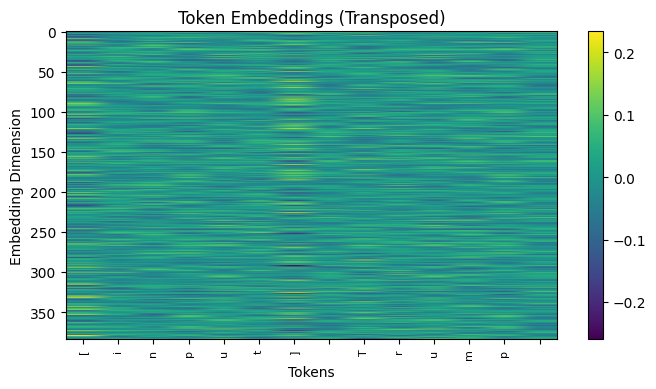

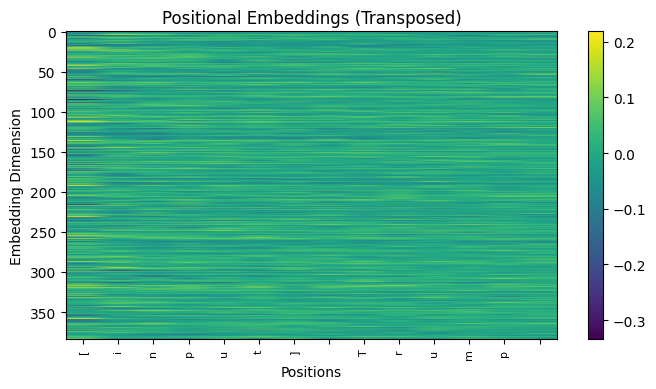

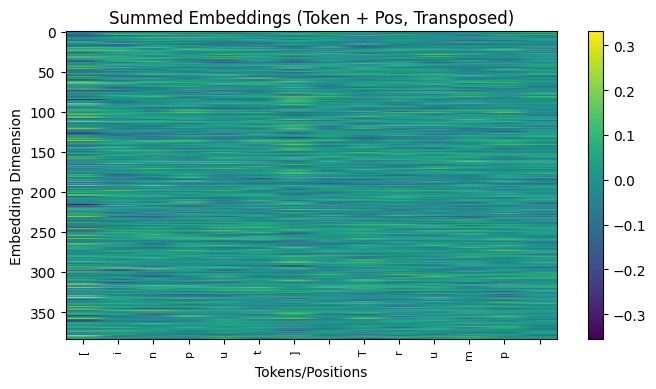

In [22]:
# CELL 6: token embedding
print("\n--- 1. Visualization of token embedding and position embedding ---")
model.eval()
with torch.no_grad():
    tok_emb = model.transformer.wte(idx_tensor)
    pos_emb = model.transformer.wpe(pos_ids[:, :seq_len]) 
    sum_emb = tok_emb + pos_emb

plot_heatmap(tok_emb.squeeze(0).cpu().numpy().T, "Token Embeddings (Transposed)", "Tokens", "Embedding Dimension", tokens_for_labels, figsize=(max(5,seq_len*0.5), 4))
plot_heatmap(pos_emb.squeeze(0).cpu().numpy().T, "Positional Embeddings (Transposed)", "Positions", "Embedding Dimension", tokens_for_labels, figsize=(max(5,seq_len*0.5), 4))
plot_heatmap(sum_emb.squeeze(0).cpu().numpy().T, "Summed Embeddings (Token + Pos, Transposed)", "Tokens/Positions", "Embedding Dimension", tokens_for_labels, figsize=(max(5,seq_len*0.5), 4))


--- 2. Visualize the evolution of word representation in each layer and the final context representation ---


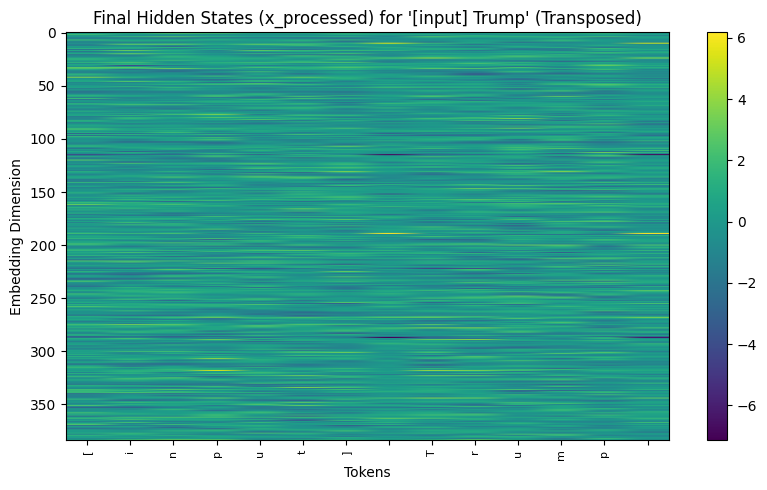

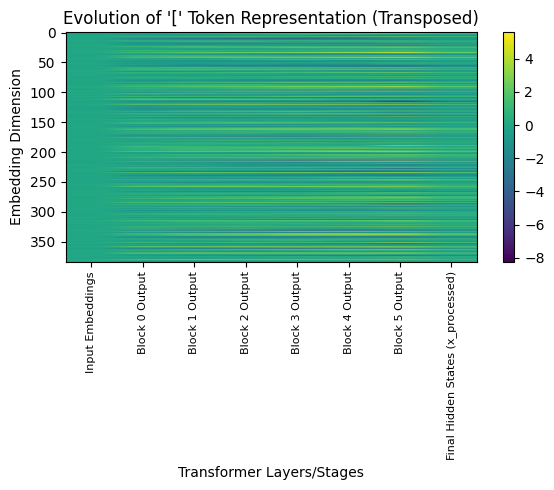


norm evolution for token '[':
Input Embeddings: 2.1302
Block 0 Output: 20.3269
Block 1 Output: 26.1549
Block 2 Output: 29.0632
Block 3 Output: 31.9185
Block 4 Output: 34.5999
Block 5 Output: 38.3487
Final Hidden States (x_processed): 22.6663


In [23]:
# CELL 7: Visualization - evolution of token representations through the layers and final contextual representation (x_processed)
print("\n--- 2. Visualize the evolution of word representation in each layer and the final context representation ---")
model.eval()
hidden_states_over_layers = []
token_to_track_str = "Trump" #
token_to_track_idx = -1
if token_to_track_str in tokens_for_labels:
    token_to_track_idx = tokens_for_labels.index(token_to_track_str)
    print(f"Tracking Tokens '{token_to_track_str}' (Index evolution in prompt: {token_to_track_idx}) ")
else:
    print(f"warning: token '{token_to_track_str}' Not in the prompt, the first token will be tracked.")
    token_to_track_idx = 0
    token_to_track_str = tokens_for_labels[0]


with torch.no_grad():
    #  (token + pos)
    current_x = model.transformer.drop(model.transformer.wte(idx_tensor) + model.transformer.wpe(pos_ids[:, :seq_len]))
    hidden_states_over_layers.append({
        "name": "Input Embeddings",
        "state": current_x.squeeze(0).cpu().numpy(),
        "token_vector": current_x.squeeze(0)[token_to_track_idx].cpu().numpy()
    })

    # Transformer Blocks
    for i, block in enumerate(model.transformer.h):
        current_x = block(current_x) 
        hidden_states_over_layers.append({
            "name": f"Block {i} Output",
            "state": current_x.squeeze(0).cpu().numpy(),
            "token_vector": current_x.squeeze(0)[token_to_track_idx].cpu().numpy()
        })

    # Final LayerNorm
    x_processed = model.transformer.ln_f(current_x)
    hidden_states_over_layers.append({
        "name": "Final Hidden States (x_processed)",
        "state": x_processed.squeeze(0).cpu().numpy(),
        "token_vector": x_processed.squeeze(0)[token_to_track_idx].cpu().numpy()
    })

# visualize final state  x_processed
plot_heatmap(x_processed.squeeze(0).cpu().numpy().T, f"Final Hidden States (x_processed) for '{start_string.strip()}' (Transposed)",
             "Tokens", "Embedding Dimension", tokens_for_labels, figsize=(max(6,seq_len*0.6), 5))

# Visualize the evolution of the vector for a specific token
token_evolution_vectors = np.array([s["token_vector"] for s in hidden_states_over_layers])
layer_names = [s["name"] for s in hidden_states_over_layers]

plot_heatmap(token_evolution_vectors.T, f"Evolution of '{token_to_track_str}' Token Representation (Transposed)",
             "Transformer Layers/Stages", "Embedding Dimension", layer_names, yticklabels=None, figsize=(max(6, len(layer_names)*0.5),5), aspect='auto')

# Print the norm of some vectors for reference
print(f"\nnorm evolution for token '{token_to_track_str}':")
for i, name in enumerate(layer_names):
    norm = np.linalg.norm(token_evolution_vectors[i])
    print(f"{name}: {norm:.4f}")


--- 3. Visualize Q, K, V vectors  ---


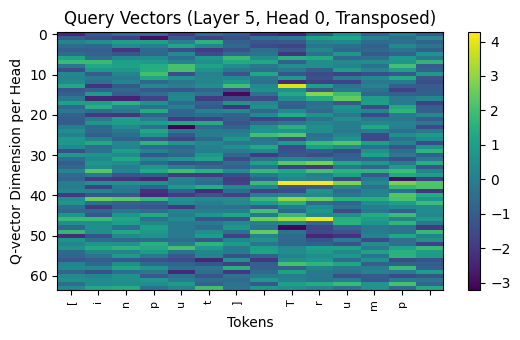

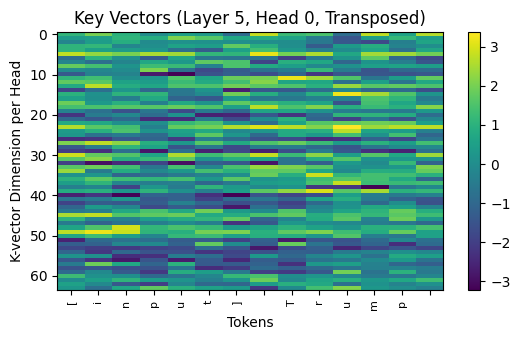

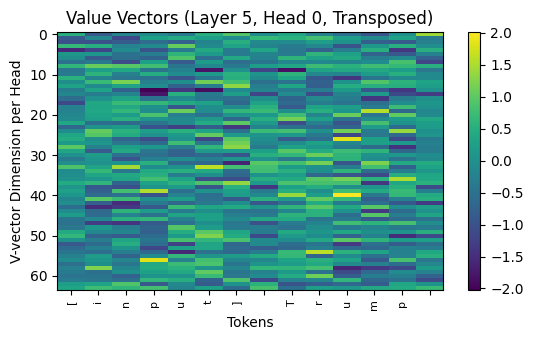

In [24]:
# CELL 8: visulization - Q, K, V  (specific head and layer)
print(f"\n--- 3. Visualize Q, K, V vectors  ---")
layer_idx_for_qkv = N_LAYER - 1 #layer to visualize
head_idx_for_qkv = 0

model.eval()
with torch.no_grad():
    # Get the input of the target Block (i.e. the output of the previous block, or the initial embedding)
    x_input_to_target_block = torch.tensor(hidden_states_over_layers[layer_idx_for_qkv]["state"], device=DEVICE).unsqueeze(0)
    
    # ln_1 of the applied target Block
    x_ln1_for_qkv = model.transformer.h[layer_idx_for_qkv].ln_1(x_input_to_target_block)
    
    # get raw qkv (B, T, 3*N_EMBD) -> (B, T, N_EMBD) for Q, K, V each
    q_raw, k_raw, v_raw = model.transformer.h[layer_idx_for_qkv].attn.c_attn(x_ln1_for_qkv).split(N_EMBD, dim=2)
    
    # Reshape to separate the head (B, N_HEAD, T, C_HEAD)
    B, T, C_full = q_raw.size()
    C_head = N_EMBD // N_HEAD
    
    q_reshaped = q_raw.view(B, T, N_HEAD, C_head).transpose(1, 2) # (B, N_HEAD, T, C_HEAD)
    k_reshaped = k_raw.view(B, T, N_HEAD, C_head).transpose(1, 2)
    v_reshaped = v_raw.view(B, T, N_HEAD, C_head).transpose(1, 2)

# visualize specific head of Q, K, V (shape: T, C_HEAD)
q_for_plot = q_reshaped[0, head_idx_for_qkv].cpu().numpy().T # (C_HEAD, T)
k_for_plot = k_reshaped[0, head_idx_for_qkv].cpu().numpy().T
v_for_plot = v_reshaped[0, head_idx_for_qkv].cpu().numpy().T

plot_heatmap(q_for_plot, f"Query Vectors (Layer {layer_idx_for_qkv}, Head {head_idx_for_qkv}, Transposed)",
             "Tokens", "Q-vector Dimension per Head", short_tokens_for_labels, figsize=(max(5,seq_len*0.4), 3.5))
plot_heatmap(k_for_plot, f"Key Vectors (Layer {layer_idx_for_qkv}, Head {head_idx_for_qkv}, Transposed)",
             "Tokens", "K-vector Dimension per Head", short_tokens_for_labels, figsize=(max(5,seq_len*0.4), 3.5))
plot_heatmap(v_for_plot, f"Value Vectors (Layer {layer_idx_for_qkv}, Head {head_idx_for_qkv}, Transposed)",
             "Tokens", "V-vector Dimension per Head", short_tokens_for_labels, figsize=(max(5,seq_len*0.4), 3.5))


--- 4. visualize attention heatmap ---
Reshape to separate the head to successfully extract the attention weights from the 5th layer.
shape: torch.Size([1, 6, 14, 14])


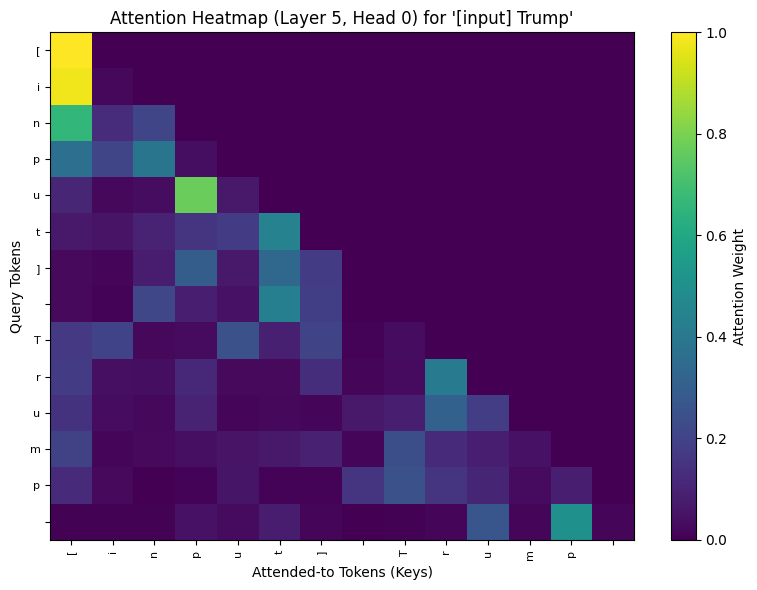

In [25]:
# CELL 9: visualization - attention heatmap
print(f"\n--- 4. visualize attention heatmap ---")
layer_to_visualize_attn = N_LAYER - 1 
head_to_visualize_attn = 0 # 第一个 head

attention_weights_viz = None
model.eval()
with torch.no_grad():
    logits_viz, _, collected_attention_weights, _, _ = model(idx_tensor, return_attention_layer_idx=layer_to_visualize_attn)
    attention_weights_viz = collected_attention_weights


if attention_weights_viz is not None:
    print(f"Reshape to separate the head to successfully extract the attention weights from the {layer_to_visualize_attn}th layer.")
    print(f"shape: {attention_weights_viz.shape}") # (B, N_HEAD, T, T)
    
    single_head_attention_viz = attention_weights_viz[0, head_to_visualize_attn].cpu().numpy() # (T, T)
    
    fig_width = max(8, seq_len * 0.5)
    fig_height = max(6, seq_len * 0.4)

    plt.figure(figsize=(fig_width, fig_height))
    plt.imshow(single_head_attention_viz, cmap='viridis', aspect='auto')
    plt.xticks(np.arange(seq_len), tokens_for_labels, rotation=90, fontsize=8)
    plt.yticks(np.arange(seq_len), tokens_for_labels, fontsize=8)
    plt.xlabel("Attended-to Tokens (Keys)")
    plt.ylabel("Query Tokens")
    plt.title(f"Attention Heatmap (Layer {layer_to_visualize_attn}, Head {head_to_visualize_attn}) for '{start_string.strip()}'")
    plt.colorbar(label="Attention Weight")
    plt.tight_layout()
    plt.show()
else:
    print(f"Failed to extract attention weights from layer {layer_to_visualize_attn}.")


--- 5. Visualize the predicted probability of the next token after the prompt (Top 10) ---


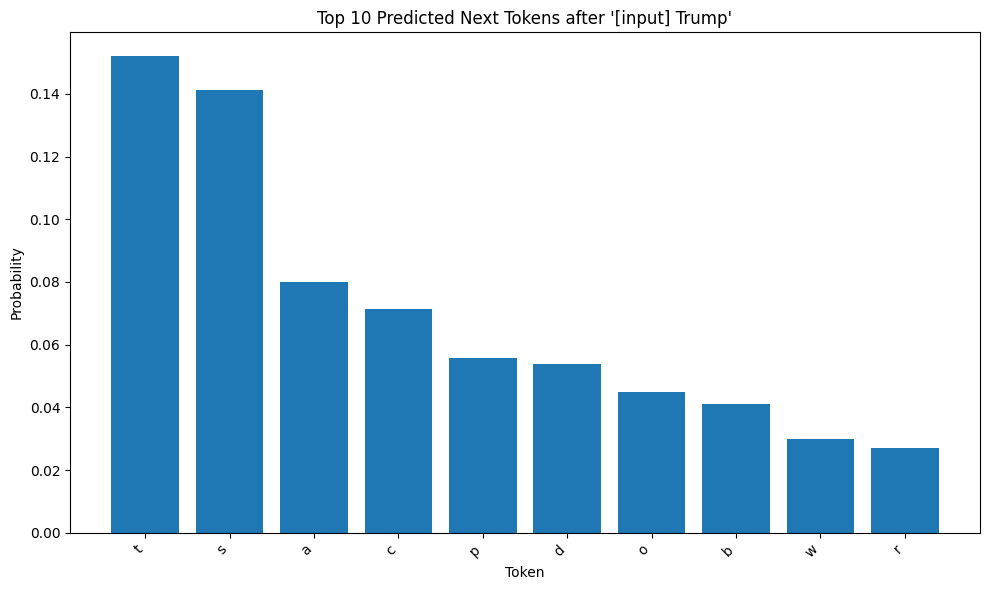

Rank 1: Token 't', Probability: 0.1520
Rank 2: Token 's', Probability: 0.1413
Rank 3: Token 'a', Probability: 0.0799
Rank 4: Token 'c', Probability: 0.0715
Rank 5: Token 'p', Probability: 0.0558
Rank 6: Token 'd', Probability: 0.0540
Rank 7: Token 'o', Probability: 0.0448
Rank 8: Token 'b', Probability: 0.0411
Rank 9: Token 'w', Probability: 0.0300
Rank 10: Token 'r', Probability: 0.0269


In [26]:
# CELL 10: Visualization - Output Probability of next token
print("\n--- 5. Visualize the predicted probability of the next token after the prompt (Top 10) ---")
model.eval()
with torch.no_grad():
    logits_for_probs, _, _, _, _ = model(idx_tensor) # Get the logits of the entire sequence

    
# We are interested in predicting the next token based on the entire input prompt
# model.forward returns the logits of the last token by default during inference (target=None, and no special visualization markup)
# If model(idx_tensor) returns logits of all tokens, we need to take the last one
# Assume logits_for_probs is (B, T, VocabSize) or (B, 1, VocabSize) if from generate path
if logits_for_probs.size(1) == idx_tensor.size(1) : # (B, T, VocabSize)
    next_token_logits = logits_for_probs[:, -1, :] # Get the logits of the last time step in the sequence
else: # (B, 1, VocabSize)
    next_token_logits = logits_for_probs.squeeze(1)


next_token_probs = F.softmax(next_token_logits, dim=-1).squeeze().cpu().numpy()

top_k = 10
top_k_probs_val, top_k_indices_val = torch.topk(torch.tensor(next_token_probs), k=top_k)
top_k_tokens_val = [decode([idx.item()]) for idx in top_k_indices_val]

plt.figure(figsize=(10, 6))
plt.bar(np.arange(top_k), top_k_probs_val.numpy(), tick_label=top_k_tokens_val)
plt.title(f"Top {top_k} Predicted Next Tokens after '{start_string.strip()}'")
plt.xlabel("Token")
plt.ylabel("Probability")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

for i in range(top_k):
    print(f"Rank {i+1}: Token '{top_k_tokens_val[i]}', Probability: {top_k_probs_val[i].item():.4f}")

In [27]:

print(f"\n--- 6. using prompt: '{start_string.strip()}' to generate ---")
max_generated_length = 300 
model.eval()
with torch.no_grad():
    generated_ids_full = model.generate(
        idx_tensor, 
        max_new_tokens=max_generated_length,
        temperature=0.7,
        top_k=50
    )
generated_text_full = decode(generated_ids_full[0].tolist())
print("\n--- generated text ---")
print(generated_text_full)


--- 6. using prompt: '[input] Trump' to generate ---

--- generated text ---
[input] Trump department environmental law program as president as a president and cruz partnership && (Reuters) - U.S. President Donald Trump has put a better confirmation on Tuesday to protect a plea that it also had made a permit of the Iranian-European Union relations were responsible for the fighting court p



--- Detailed Intermediates from a Transformer Block ---
Requesting detailed intermediates from Block 0...

Successfully extracted detailed intermediates from Block 0.


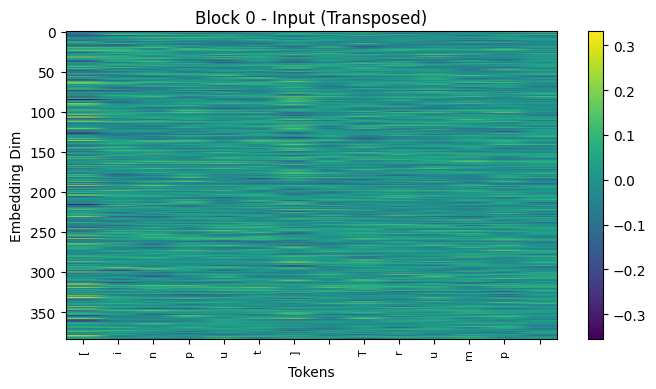

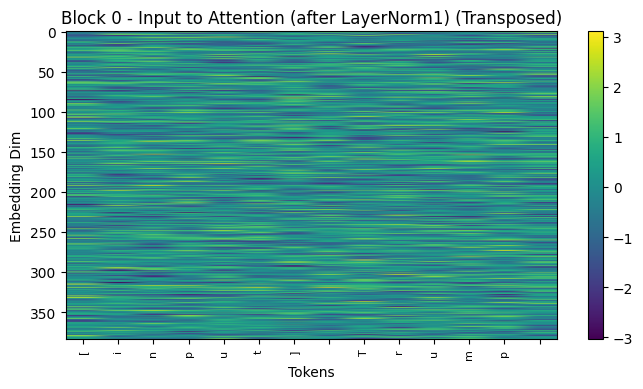


--- Attention Module Details ---


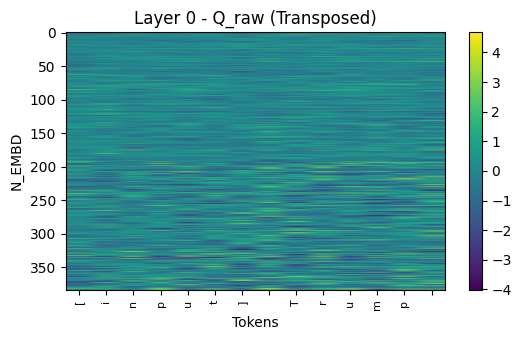

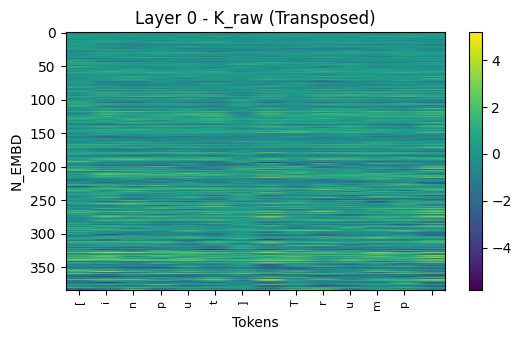

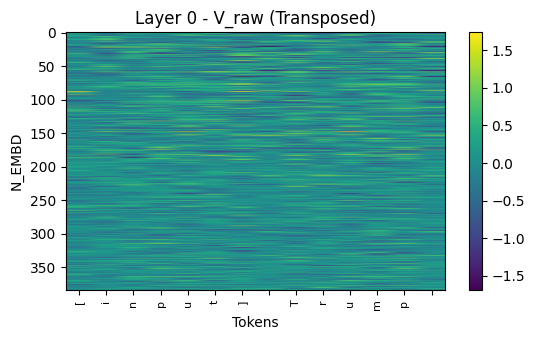

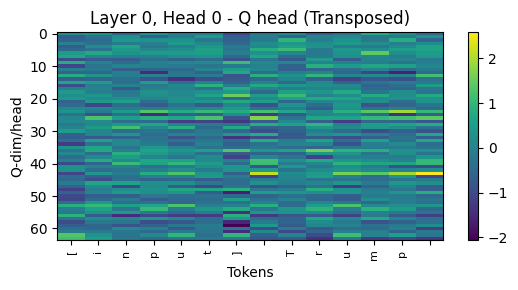

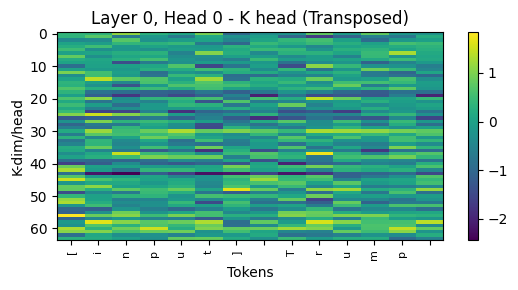

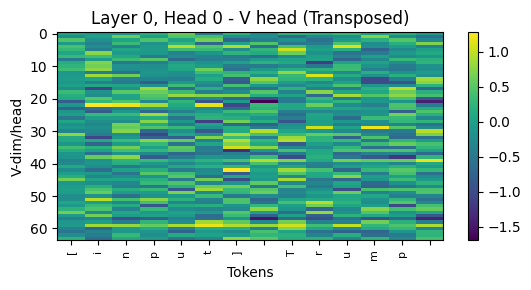

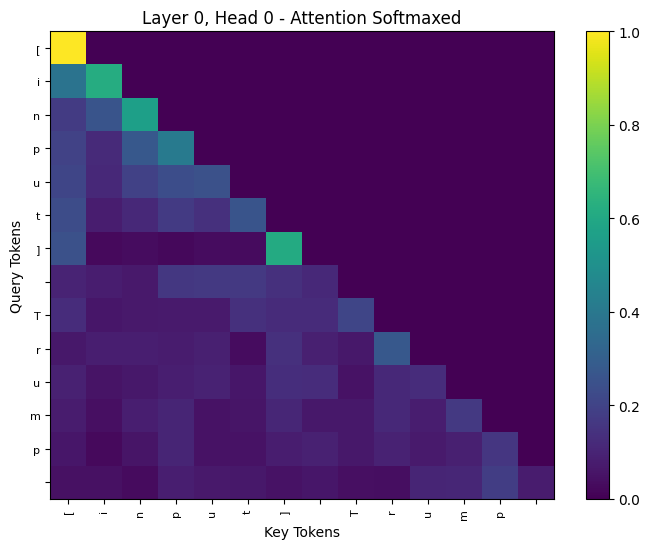

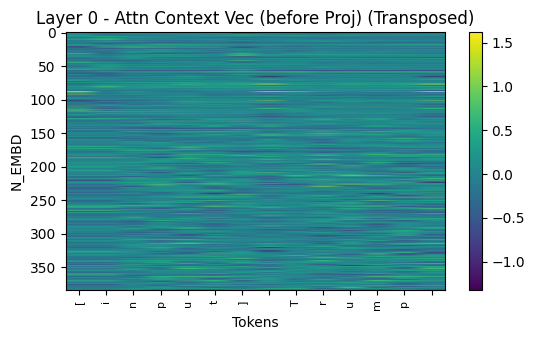

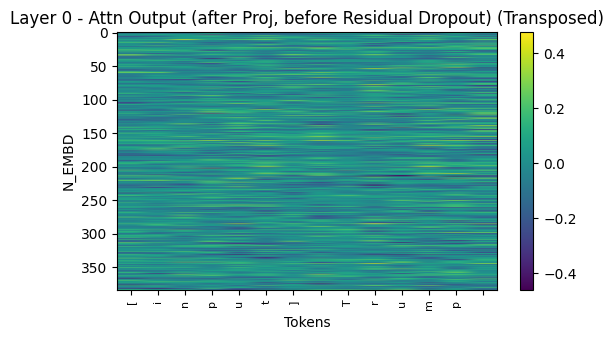

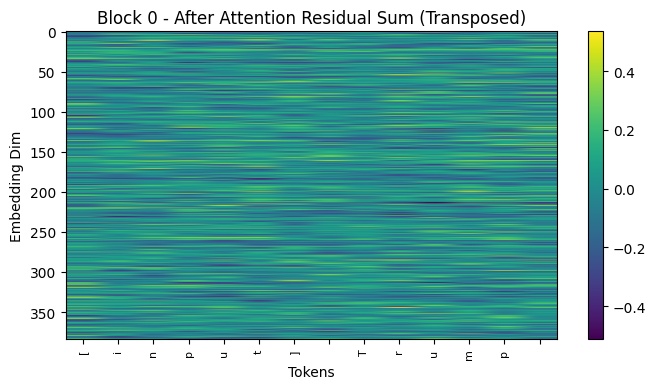


--- MLP Module Details ---


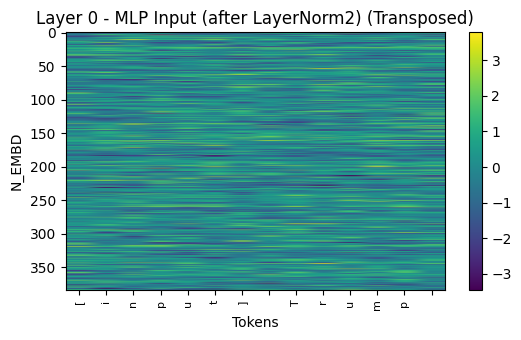

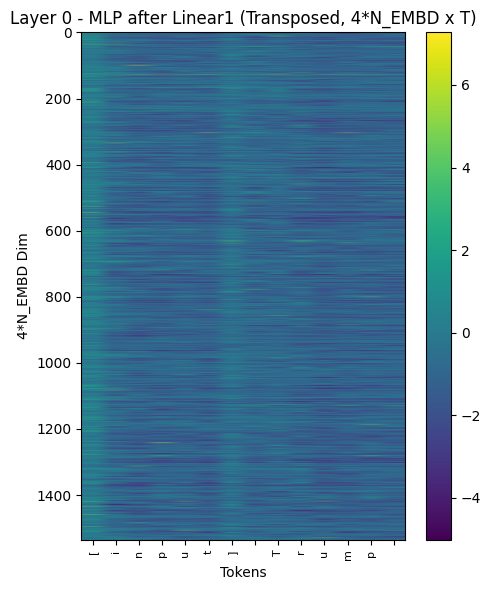

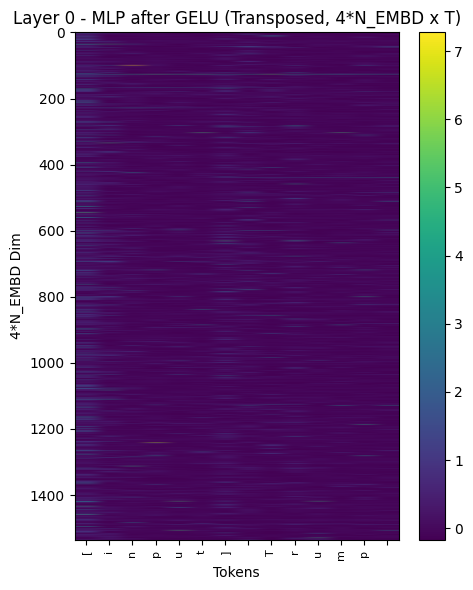

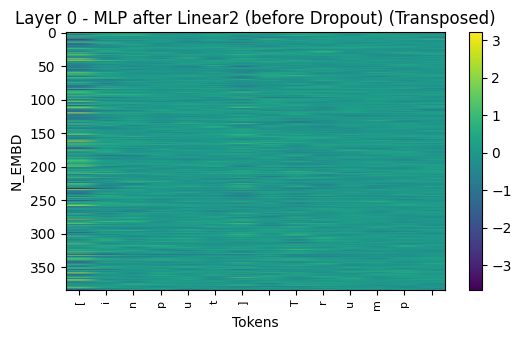

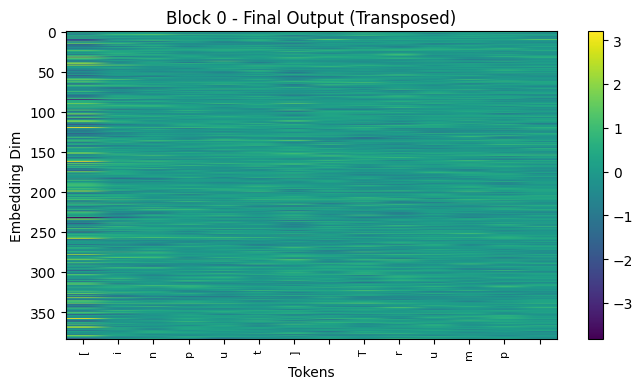

In [28]:
# CELL 11: Visualization - Detailed Intermediates from a Specific Transformer Block
print(f"\n--- Detailed Intermediates from a Transformer Block ---")

# Choose the layer to inspect (0 to N_LAYER-1)
layer_to_inspect_detailed = 0 # Example: Last layer
# layer_to_inspect_detailed = 0 # Example: First layer

print(f"Requesting detailed intermediates from Block {layer_to_inspect_detailed}...")

model.eval()
with torch.no_grad():
    # Note: The last returned value is 'collected_block_all_internal_steps'
    logits_viz, _, _, _, collected_block_details = model(
        idx_tensor, 
        return_all_internal_steps_for_layer_idx=layer_to_inspect_detailed
    )

if collected_block_details:
    print(f"\nSuccessfully extracted detailed intermediates from Block {layer_to_inspect_detailed}.")
    
    # Function to select a head if data is per-head, or keep as is
    def select_head_for_plot(tensor_data, head_idx=0):
        if tensor_data.ndim == 4: # B, H, T, C_h or B, H, T, T
            return tensor_data[0, head_idx].cpu().numpy()
        elif tensor_data.ndim == 3: # B, T, C
            return tensor_data.squeeze(0).cpu().numpy().T # Transpose to (C, T) for heatmap
        return tensor_data.cpu().numpy() # Should not happen for these specific keys

    # --- Visualize Block Level Inputs/Outputs ---
    plot_heatmap(select_head_for_plot(collected_block_details['block_input']),
                 f"Block {layer_to_inspect_detailed} - Input (Transposed)",
                 "Tokens", "Embedding Dim", short_tokens_for_labels, figsize=(max(5,seq_len*0.5), 4))
    
    plot_heatmap(select_head_for_plot(collected_block_details['attn_input_after_ln1']),
                 f"Block {layer_to_inspect_detailed} - Input to Attention (after LayerNorm1) (Transposed)",
                 "Tokens", "Embedding Dim", short_tokens_for_labels, figsize=(max(5,seq_len*0.5), 4))

    # --- Visualize Attention Module Details ---
    attn_details = collected_block_details.get('attention_module_details', {})
    if attn_details:
        print("\n--- Attention Module Details ---")
        
        # Q_raw, K_raw, V_raw (B, T, C) - These are N_EMBD dimensional
        plot_heatmap(select_head_for_plot(attn_details['q_raw_emb']),
                     f"Layer {layer_to_inspect_detailed} - Q_raw (Transposed)", "Tokens", "N_EMBD", short_tokens_for_labels, figsize=(max(5,seq_len*0.4), 3.5))
        plot_heatmap(select_head_for_plot(attn_details['k_raw_emb']),
                     f"Layer {layer_to_inspect_detailed} - K_raw (Transposed)", "Tokens", "N_EMBD", short_tokens_for_labels, figsize=(max(5,seq_len*0.4), 3.5))
        plot_heatmap(select_head_for_plot(attn_details['v_raw_emb']),
                     f"Layer {layer_to_inspect_detailed} - V_raw (Transposed)", "Tokens", "N_EMBD", short_tokens_for_labels, figsize=(max(5,seq_len*0.4), 3.5))

        # Q_heads, K_heads, V_heads (B, n_head, T, C_head) - Plot for one head
        head_to_plot_idx = 0
        plot_heatmap(select_head_for_plot(attn_details['q_heads'], head_idx=head_to_plot_idx).T, # (C_head, T) -> (T, C_head) then plot
                     f"Layer {layer_to_inspect_detailed}, Head {head_to_plot_idx} - Q head (Transposed)", "Tokens", "Q-dim/head", short_tokens_for_labels, figsize=(max(5,seq_len*0.4), 3))
        plot_heatmap(select_head_for_plot(attn_details['k_heads'], head_idx=head_to_plot_idx).T,
                     f"Layer {layer_to_inspect_detailed}, Head {head_to_plot_idx} - K head (Transposed)", "Tokens", "K-dim/head", short_tokens_for_labels, figsize=(max(5,seq_len*0.4), 3))
        plot_heatmap(select_head_for_plot(attn_details['v_heads'], head_idx=head_to_plot_idx).T,
                     f"Layer {layer_to_inspect_detailed}, Head {head_to_plot_idx} - V head (Transposed)", "Tokens", "V-dim/head", short_tokens_for_labels, figsize=(max(5,seq_len*0.4), 3))

        # Attention Scores (B, n_head, T, T) - Plot for one head
        # This is what Cell 9 visualizes.
        plot_heatmap(select_head_for_plot(attn_details['att_softmaxed_before_dropout'], head_idx=head_to_plot_idx), # (T,T)
                     f"Layer {layer_to_inspect_detailed}, Head {head_to_plot_idx} - Attention Softmaxed", "Key Tokens", "Query Tokens", tokens_for_labels, yticklabels=tokens_for_labels, figsize=(max(6,seq_len*0.5), max(5,seq_len*0.4)))

        # Context vector before final projection in Attention (B, T, C)
        plot_heatmap(select_head_for_plot(attn_details['context_vec_reshaped_before_c_proj']),
                     f"Layer {layer_to_inspect_detailed} - Attn Context Vec (before Proj) (Transposed)", "Tokens", "N_EMBD", short_tokens_for_labels, figsize=(max(5,seq_len*0.4), 3.5))
        
        # Output of c_proj in Attention (B, T, C)
        plot_heatmap(select_head_for_plot(attn_details['output_of_c_proj_before_resid_dropout']),
                     f"Layer {layer_to_inspect_detailed} - Attn Output (after Proj, before Residual Dropout) (Transposed)", "Tokens", "N_EMBD", short_tokens_for_labels, figsize=(max(5,seq_len*0.4), 3.5))

    plot_heatmap(select_head_for_plot(collected_block_details['after_attn_residual_sum']),
                 f"Block {layer_to_inspect_detailed} - After Attention Residual Sum (Transposed)",
                 "Tokens", "Embedding Dim", short_tokens_for_labels, figsize=(max(5,seq_len*0.5), 4))

    # --- Visualize MLP Module Details ---
    mlp_details = collected_block_details.get('mlp_module_details', {})
    if mlp_details:
        print("\n--- MLP Module Details ---")
        plot_heatmap(select_head_for_plot(mlp_details['mlp_input']), # This is after ln_2
                     f"Layer {layer_to_inspect_detailed} - MLP Input (after LayerNorm2) (Transposed)", "Tokens", "N_EMBD", short_tokens_for_labels, figsize=(max(5,seq_len*0.4), 3.5))

        # Output of first Linear layer in MLP (B, T, 4*N_EMBD) - This can be very large to plot directly
        # Consider plotting norm or a slice if N_EMBD is large. For now, attempt full plot.
        mlp_after_fc1 = select_head_for_plot(mlp_details['after_fc1']) # (4*N_EMBD, T)
        plot_heatmap(mlp_after_fc1,
                     f"Layer {layer_to_inspect_detailed} - MLP after Linear1 (Transposed, 4*N_EMBD x T)", "Tokens", "4*N_EMBD Dim", short_tokens_for_labels, figsize=(max(5,seq_len*0.3), 6), aspect='auto')
        
        mlp_after_gelu = select_head_for_plot(mlp_details['after_gelu']) # (4*N_EMBD, T)
        plot_heatmap(mlp_after_gelu,
                     f"Layer {layer_to_inspect_detailed} - MLP after GELU (Transposed, 4*N_EMBD x T)", "Tokens", "4*N_EMBD Dim", short_tokens_for_labels, figsize=(max(5,seq_len*0.3), 6), aspect='auto')

        plot_heatmap(select_head_for_plot(mlp_details['after_c_proj_before_dropout']),
                     f"Layer {layer_to_inspect_detailed} - MLP after Linear2 (before Dropout) (Transposed)", "Tokens", "N_EMBD", short_tokens_for_labels, figsize=(max(5,seq_len*0.4), 3.5))

    plot_heatmap(select_head_for_plot(collected_block_details['block_output_final']),
                 f"Block {layer_to_inspect_detailed} - Final Output (Transposed)",
                 "Tokens", "Embedding Dim", short_tokens_for_labels, figsize=(max(5,seq_len*0.5), 4))

else:
    print(f"Failed to retrieve detailed intermediates for Block {layer_to_inspect_detailed}.")